In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, LinearAlgebra, StatsBase;

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [3]:
pwd()

"/home/gridsan/aligho/Plasmons/Plasmons_Paper/Moire_Figs"

In [4]:
v1, v2, v3 = loadlattice("../hBN_Optimization/hBN.out")
unit_cell_area([v1, v2, v3])/(1.44^2*3*sqrt(3)/2)

1.0060422870287173

In [6]:
readlines("../hBN_Optimization/hBN.ionpos")

4-element Vector{String}:
 "# Ionic positions in lattice coordinates:"
 "ion B  -0.000000000000000   0.000000000000000   0.000000000000000 0"
 "ion N   0.333333333333333   0.666666666666667   0.000000000000000 0"
 ""

The commensuration angle is given by $cos^{-1}\Big(\frac{3q^2-p^2}{3q^2+p^2}\Big)$. For q=3, p=1, we get $\cos^{-1}(\frac{13}{14})$

In [5]:
## Rotation matrices in 2 and 3d (about z axis)
function rot(θ::Real)
    rot_matrix =[cos(θ) -sin(θ); sin(θ) cos(θ) ]
    return rot_matrix
end
function rot_3x3(θ::Real)
    rot_matrix =[cos(θ) -sin(θ) 0; sin(θ) cos(θ) 0; 0 0 1 ]
    return rot_matrix
end

rot_3x3 (generic function with 1 method)

In [6]:
# Visualize the twist angle 
θ = acos(13/14)
unit_cell_array1=zeros(600, 600);
unit_cell_array2=zeros(600, 600);
for (i, j) in Tuple.(CartesianIndices(rand(600, 600)))
    unit_cell_array1[i, j] = in_wigner_seitz([v1, v2, v3], [(i-300)/(4*48), (j-300)/(4*48), 0], n=1)
    unit_cell_array2[i, j] = in_wigner_seitz([rot_3x3(θ)*v1, rot_3x3(θ)*v2, v3], [(i-300)*1/(4*48), (j-300)*1/(4*48), 0], n=1)
end

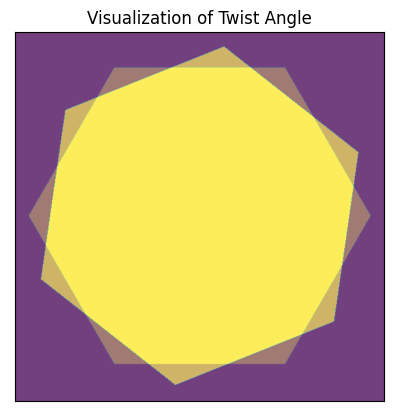

PyObject Text(0.5, 1.0, 'Visualization of Twist Angle')

In [7]:
imshow(unit_cell_array1, alpha=0.5)
imshow(unit_cell_array2, alpha=0.5)
xticks(Float64[])
yticks(Float64[])
title("Visualization of Twist Angle")

In [20]:
w1 = [1, 0]
w2 = [-1/2, √3/2]
z1 = rot(θ)*w1
z2 = rot(θ)*w2

2-element Vector{Float64}:
 -0.7857142857142857
  0.6185895741317419

In [21]:
translation = hcat(z1, z2)*superlattice_to_layer2*[2/3, 1/3]

2-element Vector{Float64}:
 -1.4999999999999998
 -0.28867513459481287

In [22]:
lattpoints1 = [[round.(((r-11)*w1+(t-11)*w2), digits=8) for (r, t) in Tuple.(CartesianIndices(rand(21, 21)))]...]
lattpoints2 = [[round.(((r-11)*z1+(t-11)*z2), digits=8) for (r, t) in Tuple.(CartesianIndices(rand(21, 21)))]...];
lattpoints3 = intersect(lattpoints1, lattpoints2);

In [23]:
points_fill = [[0, 0],  -2*w1 .+ w2  , -3w1 .- 2w2,  -w1 .- 3*w2]

4-element Vector{Vector{Float64}}:
 [0.0, 0.0]
 [-2.5, 0.8660254037844386]
 [-2.0, -1.7320508075688772]
 [0.5, -2.598076211353316]

In [24]:
println([sqrt(sum(p.^2)) for p in points_fill])

[0.0, 2.6457513110645907, 2.6457513110645907, 2.6457513110645907]


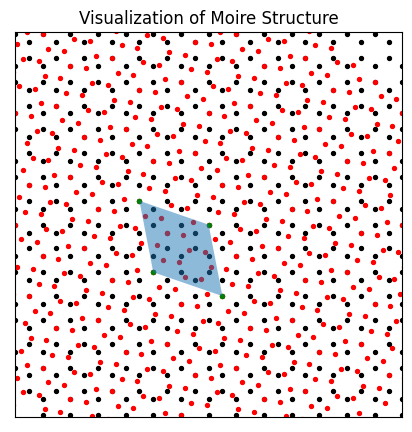

PyObject Text(0.5, 1.0, 'Visualization of Moire Structure')

In [35]:
figure(figsize=(5, 5))
[scatter(lattpoint..., color="black", 8) for lattpoint in lattpoints1]
[scatter((lattpoint .+ [0, 1/sqrt(3)])..., color="black", 8) for lattpoint in lattpoints1]

[scatter((lattpoint .+ translation)..., color="red", 8) for lattpoint in lattpoints2]

[scatter((lattpoint .+ rot(θ)*[0, 1/sqrt(3)] .+ translation )..., color="red", 8) for lattpoint in lattpoints2]
#fill([0, lattpoints3[6][1], lattpoints3[5][1], lattpoints3[12][1]], [0, lattpoints3[6][2], lattpoints3[5][2], lattpoints3[12][2]], alpha=0.5)
[scatter(lattpoint[1:2]..., color="green", 8) for lattpoint in points_fill]
fill([x[1] for x in points_fill], [x[2] for x in points_fill], alpha=0.5)
ylim(-7, 7)
xlim(-7, 7)
xticks(Float64[])
yticks(Float64[])
title("Visualization of Moire Structure")

In [8]:
θ = acos(13/14)

for (ii, jj, kk, ll) in Tuple.(CartesianIndices(rand(11, 11, 11, 11)))
    i = ii-6; j = jj-6; k = kk-6; l = ll-6
    a=[1, 0]; b=[-1/2, √3/2]
    c=rot(θ)*a; d=rot(θ)*b
    diff = i*a+b*j-c*k-d*l
    isapprox(sum(diff.^2), 0, atol=1e-6) || continue
    println(i, " ", j, " ", k, " ", l)
end

1 -4 -1 -5
-4 -5 -5 -4
4 -2 2 -4
-1 -3 -2 -3
2 -1 1 -2
-3 -2 -3 -1
5 1 4 -1
0 0 0 0
-5 -1 -4 1
3 2 3 1
-2 1 -1 2
1 3 2 3
-4 2 -2 4
4 5 5 4
-1 4 1 5


In [9]:
#We choose the linear combinations -2*a_1+a_2=-b_1+2*b_2, -a_1-3*a_2=-2*b_1-3*b_2, Let's verify that indeed works: 
a_1=[1, 0]; a_2=[-1/2, √3/2]
b_1=rot(θ)*a_1; b_2=rot(θ)*a_2
println(-2*a_1+a_2+b_1-2*b_2)
println(-a_1-3*a_2+2*b_1+3*b_2)

[0.0, 0.0]
[0.0, 0.0]


In [15]:
#Let's check the superlattice size
c_1 = -2*a_1+a_2
c_2 = -a_1-3*a_2
unit_cell_area([[c_1..., 0], [c_2..., 0], zeros(3)])/unit_cell_area([[a_1..., 0], [a_2..., 0], zeros(3)])

7.0

In [9]:
#Below we define the matrices to take things from the superlattice basis to the layer bases

In [16]:
superlattice_to_layer1 = [-2 -1; 1 -3]
superlattice_to_layer1_3x3 = [-2 -1 0; 1 -3 0; 0 0 1]

superlattice_to_layer2 = [-1 -2; 2 -3]
superlattice_to_layer2_3x3 = [-1 -2 0; 2 -3 0; 0 0 1]

layer1_to_superlattice = inv(superlattice_to_layer1)
layer2_to_superlattice = inv(superlattice_to_layer2);

In [11]:
#The general method by which we create the ions
tot_ions = 0
for i in -20:20
    for j in -20:20
        iprime, jprime = layer1_to_superlattice*[i, j]
        if (!(iprime >= 1) && !(jprime >= 1) && !(iprime < 0) && !(jprime < 0)) 
            println("ion B $iprime $jprime 0 0" )
            tot_ions+=1
        end
        iprime, jprime = layer1_to_superlattice*[i+1/3, j+2/3]
        if (!(iprime >= 1) && !(jprime >= 1) && !(iprime < 0) && !(jprime < 0)) 
            println("ion N $iprime $jprime 0 0" )
            tot_ions+=1
        end
        iprime, jprime = layer2_to_superlattice*[i, j]
        if (!(iprime >= 1) && !(jprime >= 1) && !(iprime < 0) && !(jprime < 0)) 
            println("ion B $iprime $jprime \${d} 0" )
            tot_ions+=1
        end
        iprime, jprime = layer2_to_superlattice*[i+1/3, j+2/3]
        if (!(iprime >= 1) && !(jprime >= 1) && !(iprime < 0) && !(jprime < 0)) 
            println("ion N $iprime $jprime \${d} 0" )
            tot_ions+=1
        end
    end
end
println(tot_ions)

ion N 0.9523809523809523 0.7619047619047619 0 0
ion N 0.7619047619047619 0.9523809523809523 ${d} 0
ion N 0.3809523809523811 0.9047619047619048 0 0
ion N 0.04761904761904763 0.8095238095238095 ${d} 0
ion B 0.5714285714285715 0.8571428571428571 0 0
ion N 0.523809523809524 0.6190476190476191 0 0
ion B 0.2857142857142857 0.8571428571428571 ${d} 0
ion N 0.3333333333333333 0.6666666666666666 ${d} 0
ion B 0.7142857142857144 0.5714285714285714 0 0
ion N 0.6666666666666667 0.3333333333333333 0 0
ion B 0.5714285714285714 0.7142857142857142 ${d} 0
ion N 0.6190476190476191 0.5238095238095238 ${d} 0
ion B 0.8571428571428572 0.2857142857142857 0 0
ion N 0.8095238095238096 0.04761904761904763 0 0
ion B 0.8571428571428571 0.5714285714285714 ${d} 0
ion N 0.9047619047619048 0.38095238095238093 ${d} 0
ion B 0.1428571428571429 0.7142857142857142 0 0
ion N 0.09523809523809526 0.4761904761904762 0 0
ion B 0.28571428571428575 0.42857142857142855 0 0
ion N 0.23809523809523814 0.1904761904761905 0 0
ion B 0.14

In [12]:
# Now we create the new lattice

In [17]:
[4.727486978767153   -2.363743489383575    0.000000000000000;
 -0.000000000000000    4.094123819672498    0.000000000000000;
 0.000000000000000    0.000000000000000   40.000000000000000]*superlattice_to_layer1_3x3

3×3 Matrix{Float64}:
 -11.8187     2.36374   0.0
   4.09412  -12.2824    0.0
   0.0        0.0      40.0

In [18]:
#Sanity check
rot_3x3(θ)*[4.727486978767153   -2.363743489383575    0.000000000000000;
 -0.000000000000000    4.094123819672498    0.000000000000000;
 0.000000000000000    0.000000000000000   40.000000000000000]*superlattice_to_layer2_3x3

3×3 Matrix{Float64}:
 -11.8187     2.36374   0.0
   4.09412  -12.2824    0.0
   0.0        0.0      40.0

In [58]:
# Below, we find the translations necessary to make a good Moire potential

In [22]:
translations=[]
translations_with_indices=[]
for i in -5:5
    for j in -5:5
        for k in -5:5
            for l in -5:5
                a, b = (layer1_to_superlattice*[2/3+k, 1/3+l]-layer2_to_superlattice*[2/3+i, 1/3+j])
                a < 0 && continue
                b < 0 && continue
                a >=1 && continue
                b >=1 && continue
                #println(a*sqrt(3), " ", b*3)
                a, b = round.([a, b], digits=5)
                [a, b] in translations && continue
                isequal([a,b], round.([2/3, 1/3], digits=5)) && println("$k $l $i $j")

                push!(translations, [a,b])
                push!(translations_with_indices, [k, l, i, j, a,b])

            end
        end
    end
end


-5 -4 -4 -3


In [23]:
layer1_to_superlattice*[2/3-5, 1/3-4]

2-element Vector{Float64}:
 1.3333333333333335
 1.6666666666666665

In [114]:
# Note that there are 49 total translations possible that put the hexagon centers on top of one another. 
# This makes complete sense since we have 
# Below, we show that there is only one unique tranlation

In [158]:
# The difference between two translations is
# layer1_to_superlattice*[k, l]-layer2_to_superlattice*[i, j]) 
# for some integers k, l, i and j. 
# This is equivalent to moving layer 1 by -layer1_to_superlattice*[k, l] and layer 2 by -layer2_to_superlattice*[i, j]
#Note that this is equivalent to moving layer1 by -[k, l] in the basis of layer 1's lattice vectors
#And moving layer2 by -[i, j] in the basis of layer 2's lattice vectors. Thus, both layer1 and layer2 are moved to equivalent 
#lattices

In [191]:
# We choose to translate layer2 by (2/3, 1/3) in the superlattice basis to get a Moire potential. Let's sanity check this:
println(superlattice_to_layer1*layer2_to_superlattice*([2/3+1, 1/3+1]+superlattice_to_layer2*[2/3, 1/3]))


[-0.33333333333333337, 1.333333333333333]


In [192]:
#Below, we provide two functions to write ions to files. The second function outputs the 

function write_moire_ions(tx::Real, ty::Real, io::IO)
    tot_ions = 0
    for i in -20:20
        for j in -20:20
            iprime, jprime = layer1_to_superlattice*[i, j]
            if (!(iprime >= 1) && !(jprime >= 1) && !(iprime < 0) && !(jprime < 0)) 
                write(io, "ion B $iprime $jprime 0 0\n" )
                tot_ions+=1
            end
            iprime, jprime = layer1_to_superlattice*[i+1/3, j+2/3]
            if (!(iprime >= 1) && !(jprime >= 1) && !(iprime < 0) && !(jprime < 0)) 
                write(io, "ion N $iprime $jprime 0 0\n" )
                tot_ions+=1
            end
            iprime, jprime = layer2_to_superlattice*[i, j]
            if (!(iprime >= 1) && !(jprime >= 1) && !(iprime < 0) && !(jprime < 0)) 
                write(io, "ion B $(iprime+tx) $(jprime+ty) \${d} 0\n")
                tot_ions+=1
            end
            iprime, jprime = layer2_to_superlattice*[i+1/3, j+2/3]
            if (!(iprime >= 1) && !(jprime >= 1) && !(iprime < 0) && !(jprime < 0)) 
                write(io, "ion N $(iprime+tx) $(jprime+ty) \${d} 0\n" )
                tot_ions+=1
            end
        end
    end
    (tot_ions != 28) && error("Wrong Number of Ions")
end

function write_moire_ions_reverse(tx::Real, ty::Real, io::IO)
    tot_ions = 0
    for i in -20:20
        for j in -20:20
            iprime, jprime = layer1_to_superlattice*[i, j]
            if (!(iprime >= 1) && !(jprime >= 1) && !(iprime < 0) && !(jprime < 0)) 
                write(io, "ion B $iprime $jprime 0 0\n" )
                tot_ions+=1
            end
            iprime, jprime = layer1_to_superlattice*[i+1/3, j+2/3]
            if (!(iprime >= 1) && !(jprime >= 1) && !(iprime < 0) && !(jprime < 0)) 
                write(io, "ion N $iprime $jprime 0 0\n" )
                tot_ions+=1
            end
            iprime, jprime = layer2_to_superlattice*[i, j]
            if (!(iprime >= 1) && !(jprime >= 1) && !(iprime < 0) && !(jprime < 0)) 
                write(io, "ion N $(iprime+tx) $(jprime+ty) \${d} 0\n")
                tot_ions+=1
            end
            iprime, jprime = layer2_to_superlattice*[i+1/3, j+2/3]
            if (!(iprime >= 1) && !(jprime >= 1) && !(iprime < 0) && !(jprime < 0)) 
                write(io, "ion B $(iprime+tx) $(jprime+ty) \${d} 0\n" )
                tot_ions+=1
            end
        end
    end
    (tot_ions != 28) && error("Wrong Number of Ions")
end

write_moire_ions_reverse (generic function with 1 method)

In [193]:
open("Moire7-0.666-0.333.ionpos", "w") do io
    write_moire_ions(2/3, 1/3, io)
end
open("Moire7-0.666-0.333-reverse.ionpos", "w") do io
    write_moire_ions_reverse(2/3, 1/3, io)
end

false